## Library Import

In [1]:
from tqdm import tqdm # progress bar

import pandas as pd
import numpy as np
import cv2
import os     # import os to accsses folders
import matplotlib.pyplot as plt
import seaborn as sns

# scaling and splitting
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# models
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression

# evaluation ----
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score,roc_curve, roc_auc_score, auc
from sklearn.decomposition import PCA

# **1- DATA EXPLORATION**

In [2]:
# reading dataset paths
dataset_path = r"C:\Users\dohah\Documents\Projects\Detecting Malaria Model\MachineLearningProject\img_dataset"

Parasitized_path = os.path.join(dataset_path, 'Parasitized')
Uninfected_path = os.path.join(dataset_path, 'Uninfected')

In [3]:
# loading images without any processing
def load_images_simple(folder_path, label):
    images = [] # list to store images
    labels = [] # list to store labels
    count = 0 # counter for images

    for root, dirs, files in os.walk(folder_path): # root: current directory, dirs: subdirectories, files: files in current directory(images)
        for filename in tqdm(files, desc=f"Loading {folder_path}"): #--need a look    # tqdm for progress bar means showing progress of loading images 
            if not filename.lower().endswith((".png", ".jpg", ".jpeg")): # skip non-images
                continue
            img_path = os.path.join(root, filename)
            img = cv2.imread(img_path,0)    # color mode -> 1 , grayscale -> 0 , unchanged -> -1
            if img is None:
                continue

            images.append(img)
            labels.append(label)
            count += 1

    return images, labels, count

In [4]:
# load images
parasitized_images, parasitized_labels, count_p = load_images_simple(Parasitized_path, 1)
uninfected_images, uninfected_labels, count_u = load_images_simple(Uninfected_path, 0)

# images count
print("Parasitized images loaded: ",count_p)
print("Uninfected images loaded: ",count_u)
print("Total images loaded: ",count_p + count_u)


Loading C:\Users\dohah\Documents\Projects\Detecting Malaria Model\MachineLearningProject\img_dataset\Parasitized: 100%|██████████| 9955/9955 [02:59<00:00, 55.52it/s]
Loading C:\Users\dohah\Documents\Projects\Detecting Malaria Model\MachineLearningProject\img_dataset\Uninfected: 100%|██████████| 9955/9955 [03:29<00:00, 47.52it/s]

Parasitized images loaded:  9954
Uninfected images loaded:  9954
Total images loaded:  19908


# **2- DATA PREPROCESSING**

In [5]:
# preprocessing function
def img_preprocessing(images , target_size = (64,64)):
    processed = []    # list to store processed images, if we append on "images" it will modify the original images
    for img in images:
        img_resized = cv2.resize(img, target_size)                    # resize           ---  64x64   -the reason of 64: reduce computational load while retaining
        img_norm = img_resized.astype('float32') / 255.0              # normalization    ---  by making pixel from [0,255] to [0,1]
        img_flat = img_norm.flatten()                                 # flatten          ---  from 2D to 1D array
        processed.append(img_flat)
    return processed

In [6]:
# preprocessing -> resize, normalize, flatten
parasitized_images = img_preprocessing(parasitized_images)
uninfected_images = img_preprocessing(uninfected_images)

processed_images = parasitized_images + uninfected_images

In [7]:
# convert to numpy arrays     so we can use them in models
X = np.array(processed_images)     # for Kmeans and the features for Logistic Regression
y = np.array(parasitized_labels + uninfected_labels)   # labels for Logistic Regression 

for K-means

In [8]:
# feature scaling for K-means
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [9]:
print("X shape:",X.shape)
print("y shape:",y.shape)

X shape: (19908, 4096)
y shape: (19908,)


for LR

In [10]:
# split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y   #need a look   # to maintain the proportion of classes in both train and test sets
)

In [11]:
# feature scaling for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **3- MODEL TRAINING**

## 3.a- K-MEANS MODEL

In [12]:
# K-means

kmeans = KMeans(n_clusters=2, random_state=12)
labels = kmeans.fit_predict(X)

print(labels[:20])

[1 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 1 0 0 0]


## 3.b- LOGISTIC REGRESSION MODEL

In [13]:
# after scaling the accuuracy looks bad --asking--
lr = LogisticRegression(solver='saga', max_iter=500)
lr.fit(X_train_scaled, y_train)

y_pred = lr.predict(X_test_scaled)

C:\Users\dohah\AppData\Roaming\Python\Python310\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [14]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy on test set: ",acc)

Accuracy on test set:  0.6012054244098443


# **4- EVALUATION**

## Graphs for LR

##### **Confusion Matrix**

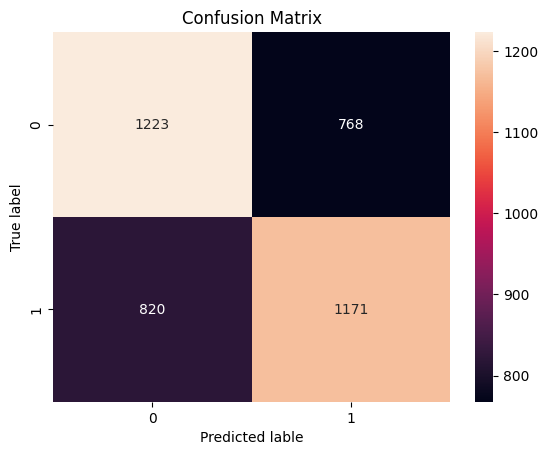

In [15]:
# see whats wrong
cm = confusion_matrix(y_test, y_pred)  

cm_df = pd.DataFrame(cm,
                     index= [0,1],
                     columns= [0,1])

sns.heatmap(cm_df, fmt='d', annot= True) # fmt='d' -> d means integer nombers will show
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted lable')
plt.show()


##### **ROC**

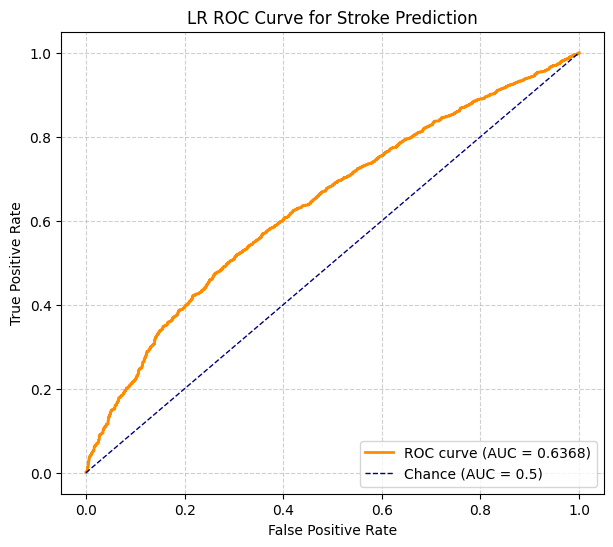

In [18]:
#     ---- need a check ----

# احتمالات الكلاس 1 فقط
y_score = lr.predict_proba(X_test)[:, 1]

# حساب FPR و TPR و AUC
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = roc_auc_score(y_test, y_score)
# رسم منحنى ROC
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Chance (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('LR ROC Curve for Stroke Prediction')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


## Graphs for KNN

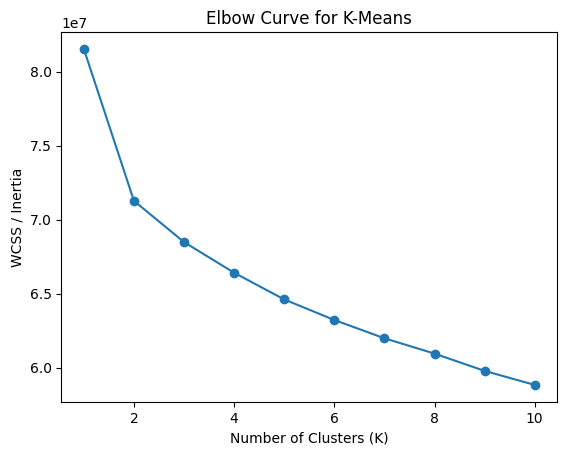

In [21]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
K_range = range(1, 11)   # جرّبي K من 1 إلى 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)        # X = flattened images
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.title('Elbow Curve for K-Means')
plt.show()
